<a href="https://colab.research.google.com/github/sanmquin/AI/blob/main/src/Graphiko/Fetch-Business-Cluster-Videos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fetch videos for business-cluster channels
This notebook reuses the Graphiko business-cluster lookup logic and then fetches Finder videos grouped by channel.


In [9]:
# Install runtime dependencies
!pip install -q pymongo dnspython pinecone pandas numpy matplotlib seaborn

import pymongo
from pymongo import MongoClient
from google.colab import userdata

try:
    # Retrieve the URI from Colab Secrets
    uri = userdata.get('MONGODB_URI')
    client = MongoClient(uri)

    # Send a ping to confirm connection
    client.admin.command('ping')
    print('✅ Successfully connected to MongoDB!')
except Exception as e:
    print(f'❌ MongoDB connection failed: {e}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 742.8/742.8 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.7/280.7 kB 19.5 MB/s eta 0:00:00
✅ Successfully connected to MongoDB!


In [2]:
# Access Finder DB collections and identify the latest business cluster
db = client['finder']
clusters_col = db['ChannelDescriptions_clusters']
items_col = db['ChannelDescriptions_items']
channels_col = db['channels']
videos_col = db['videos']

latest = clusters_col.find_one(sort=[('version', -1), ('createdAt', -1)])
latest_version = latest['version'] if latest else None
print('Latest cluster version:', latest_version)

if latest_version is None:
    print('No clusters found.')
    business_cluster = None
else:
    business_cluster = clusters_col.find_one({
        'version': latest_version,
        'name': {'$regex': '^business', '$options': 'i'}
    })

if business_cluster:
    business_cluster_id = business_cluster['_id']
    print('Business cluster found:', business_cluster.get('name'))
    print('Business cluster _id:', business_cluster_id)
else:
    business_cluster_id = None
    print('No business cluster found in the latest version.')


Latest cluster version: 2
Business cluster found: Business, Venture Capital, and Entrepreneurship
Business cluster _id: 69e41878685f30ed081ec5a6


In [3]:
# Resolve channels associated with the business cluster
if business_cluster_id is None:
    print('Cannot fetch channels without a business cluster id.')
    channel_ids = []
    business_channels = []
else:
    item_docs = list(items_col.find(
        {'clusterId': business_cluster_id},
        {'_id': 0, 'textId': 1}
    ))
    channel_ids = [d['textId'] for d in item_docs]

    business_channels = list(channels_col.find(
        {'channelId': {'$in': channel_ids}},
        {'_id': 0, 'channelId': 1, 'title': 1, 'description': 1}
    ))

    print(f'Business cluster has {len(channel_ids)} channel ids and {len(business_channels)} channel docs.')
    for ch in sorted(business_channels, key=lambda x: x.get('title', ''))[:20]:
        print(f"- {ch.get('title', '(untitled)')} ({ch.get('channelId')})")

    if len(business_channels) > 20:
        print(f'... and {len(business_channels) - 20} more channels')


Business cluster has 27 channel ids and 27 channel docs.
- 20VC with Harry Stebbings (UCf0PBRjhf0rF8fWBIxTuoWA)
- ARK Invest (UCK-zlnUfoDHzUwXcbddtnkg)
- Alex Hormozi (UCUyDOdBWhC1MCxEjC46d-zw)
- All-In Podcast (UCESLZhusAkFfsNsApnjF_Cg)
- Anthony Pompliano (UCevXpeL8cNyAnww-NqJ4m2w)
- Asianometry (UC1LpsuAUaKoMzzJSEt5WImw)
- Bg2 Pod (UC-yRDvpR99LUc5l7i7jLzew)
- Bloomberg Originals (UCUMZ7gohGI9HcU9VNsr2FJQ)
- Dan Martell (UCA-mWX9CvCTVFWRMb9bKc9w)
- Garry Tan (UCIBgYfDjtWlbJhg--Z4sOgQ)
- Greg Isenberg (UCPjNBjflYl0-HQtUvOx0Ibw)
- Joe Lonsdale (UCJEDniyP_YtcsXikBELqicw)
- Lenny's Podcast (UC6t1O76G0jYXOAoYCm153dA)
- My First Million (UCyaN6mg5u8Cjy2ZI4ikWaug)
- Network State Podcast (UCKrpnfpTwncQ050VFXcVkuQ)
- Patrick Boyle (UCASM0cgfkJxQ1ICmRilfHLw)
- Peter H. Diamandis (UCvxm0qTrGN_1LMYgUaftWyQ)
- Principles by Ray Dalio (UCqvaXJ1K3HheTPNjH-KpwXQ)
- Real Vision Presents (UCBH5VZE_Y4F3CMcPIzPEB5A)
- Sequoia Capital (UCWrF0oN6unbXrWsTN7RctTw)
... and 7 more channels


## Fetch videos for each business-cluster channel
Retrieves videos from Finder's `videos` collection for all channels in the business cluster and groups them by `channelId`.


In [5]:
from collections import defaultdict

if not channel_ids:
    print('No channel ids available to query videos.')
    videos_by_channel = {}
else:
    cursor = videos_col.find(
        {'channelId': {'$in': channel_ids}},
        {
            '_id': 0,
            'videoId': 1,
            'channelId': 1,
            'title': 1,
            'publishedAt': 1,
            'viewCount': 1
        }
    ).sort([('channelId', 1), ('publishedAt', -1)])

    videos_by_channel = defaultdict(list)
    for doc in cursor:
        videos_by_channel[doc['channelId']].append(doc)

    print(f'Fetched videos for {len(videos_by_channel)} channels.')
    total_videos = sum(len(v) for v in videos_by_channel.values())
    print(f'Total videos fetched: {total_videos}')

    for channel in business_channels:
        cid = channel.get('channelId')
        title = channel.get('title', '(untitled)')
        channel_videos = videos_by_channel.get(cid, [])
        print(f'{title} ({cid}) -> {len(channel_videos)} videos')

        # Show up to 3 most recent videos for quick inspection
        for video in channel_videos[:3]:
            print(
                f"  • {video.get('title', '(no title)')} "
                f"| views={video.get('viewCount')} | published={video.get('publishedAt')}"
            )


Fetched videos for 27 channels.
Total videos fetched: 1344
Bg2 Pod (UC-yRDvpR99LUc5l7i7jLzew) -> 44 videos
  • ChatGPT – The Super Assistant Era | BG2 Guest Interview | views=7574 | published=2026-03-15 16:25:13
  • AI Enterprise - Databricks & Glean | BG2 Guest Interview | views=24210 | published=2025-12-23 23:15:04
  • All things AI w @altcap @sama & @satyanadella.  A Halloween Special.  🎃🔥BG2 w/ Brad Gerstner | views=228167 | published=2025-10-31 23:17:31
The Prof G Pod – Scott Galloway (UC1E1SVcVyU3ntWMSQEp38Yw) -> 50 videos
  • The Hidden Engine of China’s AI Boom | China Decode | views=17697 | published=2026-04-21 08:00:53
  • Why the SpaceX IPO Doesn't Add Up | Office Hours | views=20314 | published=2026-04-20 16:01:35
  • S&P and Nasdaq Hit Record Highs as Investors Look Past War | Prof G Markets | views=24154 | published=2026-04-20 11:05:00
Asianometry (UC1LpsuAUaKoMzzJSEt5WImw) -> 50 videos
  • How To Test 208 Billion Transistors | views=149040 | published=2026-04-12 23:00:26

In [7]:
# Optional: flatten all fetched videos to a DataFrame for downstream analysis/export
import pandas as pd

all_videos = [v for vids in videos_by_channel.values() for v in vids] if videos_by_channel else []
videos_df = pd.DataFrame(all_videos)
print('videos_df shape:', videos_df.shape)
videos_df.head(10)


videos_df shape: (1344, 5)


,videoId,channelId,publishedAt,title,viewCount
0,MIKej1HCRW0,UC-yRDvpR99LUc5l7i7jLzew,2026-03-15 16:25:13,ChatGPT – The Super Assistant Era | BG2 Guest ...,7574
1,jA8ZQfq_Hzs,UC-yRDvpR99LUc5l7i7jLzew,2025-12-23 23:15:04,AI Enterprise - Databricks & Glean | BG2 Guest...,24210
2,Gnl833wXRz0,UC-yRDvpR99LUc5l7i7jLzew,2025-10-31 23:17:31,All things AI w @altcap @sama & @satyanadella....,228167
3,KX6q6lvoYtM,UC-yRDvpR99LUc5l7i7jLzew,2025-10-14 23:56:17,"AI Bubble, Stablecoin Boom, and Runnin' Down a...",71463
4,pE6sw_E9Gh0,UC-yRDvpR99LUc5l7i7jLzew,2025-09-26 03:36:04,"NVIDIA: OpenAI, Future of Compute, and the Ame...",426866
5,yLTSqBzKG2s,UC-yRDvpR99LUc5l7i7jLzew,2025-09-11 21:25:36,Inside OpenAI Enterprise: Forward Deployed Eng...,23451
6,hUJz55AsUz4,UC-yRDvpR99LUc5l7i7jLzew,2025-08-28 23:51:07,"China, China, China. Breaking Down China’s Tec...",114510
7,fTqINzeudJ4,UC-yRDvpR99LUc5l7i7jLzew,2025-07-31 15:25:00,"China Open-Source, Compute Arms Race, Reorderi...",54888
8,X52BNWZrXSk,UC-yRDvpR99LUc5l7i7jLzew,2025-07-10 23:23:42,"Michael Dell – Invest America Act Becomes Law,...",75922
9,IOoRXSyezBE,UC-yRDvpR99LUc5l7i7jLzew,2025-06-21 16:36:30,Coatue Pt2. Open AI’s Kevin Weil Dives into Al...,42867


## Pinecone embedding workflow (reused fetch-or-embed pattern)
This section reuses the same **fetch then embed-if-missing** design used in `Embeddings-Graph.ipynb` (`get_or_create_channel_description_embeddings`) and generalizes it into a helper for both:
- channel descriptions (`ChannelDescriptions` namespace)
- video titles (`VideoTitles` namespace)

That gives idempotent runs: existing vectors are fetched, and only missing records are embedded/upserted.


In [10]:
from pinecone import Pinecone

try:
    pinecone_api_key = userdata.get('PINECONE_API_KEY')
    pc = Pinecone(api_key=pinecone_api_key)
    pinecone_index = pc.Index('finder')
    print('✅ Connected to Pinecone index: finder')
except Exception as e:
    print(f'❌ Pinecone connection failed: {e}')


✅ Connected to Pinecone index: finder


In [15]:
import numpy as np

def fetch_or_embed_texts(
    pc_client,
    index,
    namespace,
    id_to_text,
    model="multilingual-e5-large",
    batch_size=96
):
    """
    1) Fetch existing vectors by id from Pinecone.
    2) Embed missing texts.
    3) Upsert missing vectors.
    4) Return dict[str, list[float]].
    """

    # Normalize keys once, so ids and text lookups stay consistent
    normalized = {
        str(k): v for k, v in id_to_text.items()
        if v is not None and str(v).strip() != ""
    }

    ids = list(normalized.keys())
    embeddings = {}

    # Fetch existing vectors
    for i in range(0, len(ids), batch_size):
        batch_ids = ids[i:i + batch_size]
        response = index.fetch(ids=batch_ids, namespace=namespace)
        vectors = getattr(response, "vectors", {}) or {}

        for rid, payload in vectors.items():
            values = payload.get("values") if isinstance(payload, dict) else getattr(payload, "values", None)
            if values is not None:
                embeddings[rid] = values

    # Embed missing vectors
    missing_ids = [rid for rid in ids if rid not in embeddings]

    for i in range(0, len(missing_ids), batch_size):
        batch_missing = missing_ids[i:i + batch_size]
        input_texts = [normalized[rid] for rid in batch_missing]

        embed_resp = pc_client.inference.embed(
            model=model,
            inputs=input_texts,
            parameters={"input_type": "passage"}
        )

        rows = getattr(embed_resp, "data", embed_resp)

        to_upsert = []
        for rid, row in zip(batch_missing, rows):
            # Pinecone returns "values", not "embedding"
            values = row.get("values") if isinstance(row, dict) else getattr(row, "values", None)
            if values is None:
                raise ValueError(f"No embedding values returned for id={rid}")

            embeddings[rid] = values
            to_upsert.append({
                "id": rid,
                "values": values,
                "metadata": {"text": normalized[rid][:1000]}
            })

        if to_upsert:
            index.upsert(vectors=to_upsert, namespace=namespace)

    return embeddings


In [16]:
# Build text dictionaries for embedding workloads
channel_desc_text = {
    str(ch.get('channelId')): (ch.get('description') or '').strip()
    for ch in business_channels
    if ch.get('channelId') and (ch.get('description') or '').strip()
}

video_title_text = {}
for cid, vids in videos_by_channel.items():
    for v in vids:
        vid = str(v.get('videoId')) if v.get('videoId') else None
        title = (v.get('title') or '').strip()
        if vid and title:
            video_title_text[vid] = title

print(f'Channels with descriptions: {len(channel_desc_text)}')
print(f'Videos with titles: {len(video_title_text)}')


Channels with descriptions: 27
Videos with titles: 1344


In [17]:
channel_desc_embeddings = fetch_or_embed_texts(
    pc_client=pc,
    index=pinecone_index,
    namespace='ChannelDescriptions',
    id_to_text=channel_desc_text,
)

video_title_embeddings = fetch_or_embed_texts(
    pc_client=pc,
    index=pinecone_index,
    namespace='VideoTitles',
    id_to_text=video_title_text,
)

print(f'Channel-description embeddings available: {len(channel_desc_embeddings)}')
print(f'Video-title embeddings available: {len(video_title_embeddings)}')


Channel-description embeddings available: 27
Video-title embeddings available: 1344


## Distance analysis and per-channel correlation
For each video we compute cosine distance to its channel-description vector:

\[
	ext{cosine distance}(v, c) = 1 -
rac{v \cdot c}{\|v\|\|c\|}
\]

Then for each channel we report:
- average and median distance
- Pearson and Spearman correlation of **distance vs viewCount** (channels with at least 3 videos with numeric view counts)

Interpretation: negative correlation means closer-to-description videos tend to get higher views.


In [18]:
import pandas as pd

def cosine_distance(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return np.nan
    return 1.0 - float(np.dot(a, b) / denom)

channel_desc_lookup = {str(ch.get('channelId')): ch for ch in business_channels if ch.get('channelId')}
records = []
for cid, vids in videos_by_channel.items():
    cid = str(cid)
    ch_vec = channel_desc_embeddings.get(cid)
    if ch_vec is None:
        continue
    for v in vids:
        vid = str(v.get('videoId')) if v.get('videoId') else None
        v_vec = video_title_embeddings.get(vid)
        if v_vec is None:
            continue
        records.append({
            'channelId': cid,
            'channelTitle': channel_desc_lookup.get(cid, {}).get('title'),
            'videoId': vid,
            'videoTitle': v.get('title'),
            'viewCount': pd.to_numeric(v.get('viewCount'), errors='coerce'),
            'publishedAt': v.get('publishedAt'),
            'distance_to_channel_description': cosine_distance(v_vec, ch_vec),
        })

distance_df = pd.DataFrame(records)
print('Distance dataset shape:', distance_df.shape)
distance_df.head(10)


Distance dataset shape: (1344, 7)


,channelId,channelTitle,videoId,videoTitle,viewCount,publishedAt,distance_to_channel_description
0,UC-yRDvpR99LUc5l7i7jLzew,Bg2 Pod,MIKej1HCRW0,ChatGPT – The Super Assistant Era | BG2 Guest ...,7574,2026-03-15 16:25:13,0.171154
1,UC-yRDvpR99LUc5l7i7jLzew,Bg2 Pod,jA8ZQfq_Hzs,AI Enterprise - Databricks & Glean | BG2 Guest...,24210,2025-12-23 23:15:04,0.168371
2,UC-yRDvpR99LUc5l7i7jLzew,Bg2 Pod,Gnl833wXRz0,All things AI w @altcap @sama & @satyanadella....,228167,2025-10-31 23:17:31,0.121647
3,UC-yRDvpR99LUc5l7i7jLzew,Bg2 Pod,KX6q6lvoYtM,"AI Bubble, Stablecoin Boom, and Runnin' Down a...",71463,2025-10-14 23:56:17,0.126358
4,UC-yRDvpR99LUc5l7i7jLzew,Bg2 Pod,pE6sw_E9Gh0,"NVIDIA: OpenAI, Future of Compute, and the Ame...",426866,2025-09-26 03:36:04,0.128379
5,UC-yRDvpR99LUc5l7i7jLzew,Bg2 Pod,yLTSqBzKG2s,Inside OpenAI Enterprise: Forward Deployed Eng...,23451,2025-09-11 21:25:36,0.146812
6,UC-yRDvpR99LUc5l7i7jLzew,Bg2 Pod,hUJz55AsUz4,"China, China, China. Breaking Down China’s Tec...",114510,2025-08-28 23:51:07,0.148546
7,UC-yRDvpR99LUc5l7i7jLzew,Bg2 Pod,fTqINzeudJ4,"China Open-Source, Compute Arms Race, Reorderi...",54888,2025-07-31 15:25:00,0.113949
8,UC-yRDvpR99LUc5l7i7jLzew,Bg2 Pod,X52BNWZrXSk,"Michael Dell – Invest America Act Becomes Law,...",75922,2025-07-10 23:23:42,0.159122
9,UC-yRDvpR99LUc5l7i7jLzew,Bg2 Pod,IOoRXSyezBE,Coatue Pt2. Open AI’s Kevin Weil Dives into Al...,42867,2025-06-21 16:36:30,0.149231


In [19]:
def safe_corr(x, y, method='pearson'):
    df = pd.DataFrame({'x': x, 'y': y}).dropna()
    if len(df) < 3:
        return np.nan
    return df['x'].corr(df['y'], method=method)

channel_corr_rows = []
for cid, g in distance_df.groupby('channelId'):
    channel_corr_rows.append({
        'channelId': cid,
        'channelTitle': g['channelTitle'].iloc[0],
        'n_videos': int(len(g)),
        'mean_distance': float(g['distance_to_channel_description'].mean()),
        'median_distance': float(g['distance_to_channel_description'].median()),
        'pearson_distance_vs_views': safe_corr(g['distance_to_channel_description'], g['viewCount'], method='pearson'),
        'spearman_distance_vs_views': safe_corr(g['distance_to_channel_description'], g['viewCount'], method='spearman'),
    })

channel_corr_df = pd.DataFrame(channel_corr_rows).sort_values('n_videos', ascending=False)
print('Channels with computed metrics:', channel_corr_df.shape[0])
channel_corr_df.head(20)


Channels with computed metrics: 27


,channelId,channelTitle,n_videos,mean_distance,median_distance,pearson_distance_vs_views,spearman_distance_vs_views
1,UC1E1SVcVyU3ntWMSQEp38Yw,The Prof G Pod – Scott Galloway,50,0.233367,0.223178,-0.128080,0.238896
2,UC1LpsuAUaKoMzzJSEt5WImw,Asianometry,50,0.244530,0.243691,-0.143795,-0.194718
3,UC6t1O76G0jYXOAoYCm153dA,Lenny's Podcast,50,0.211783,0.214689,0.293708,0.165138
7,UCBH5VZE_Y4F3CMcPIzPEB5A,Real Vision Presents,50,0.176090,0.175212,0.382920,0.467851
4,UC9cn0TuPq4dnbTY-CBsm8XA,a16z,50,0.172470,0.174738,0.020668,0.027419
5,UCA-mWX9CvCTVFWRMb9bKc9w,Dan Martell,50,0.175747,0.176865,-0.101585,-0.188187
6,UCASM0cgfkJxQ1ICmRilfHLw,Patrick Boyle,50,0.230766,0.232633,0.246023,0.409748
9,UCIBgYfDjtWlbJhg--Z4sOgQ,Garry Tan,50,0.197112,0.198509,-0.157507,-0.166675
8,UCESLZhusAkFfsNsApnjF_Cg,All-In Podcast,50,0.195308,0.194334,-0.086988,-0.111645
10,UCIHdDJ0tjn_3j-FS7s_X1kQ,Valuetainment,50,0.230461,0.230197,0.195993,0.258968


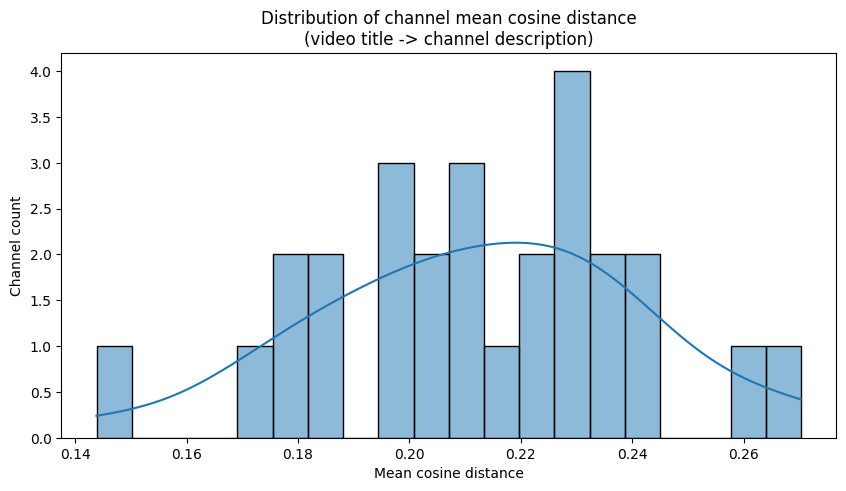

/tmp/ipykernel_4372/2672401787.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='channelTitle', y='spearman_distance_vs_views', palette='vlag')


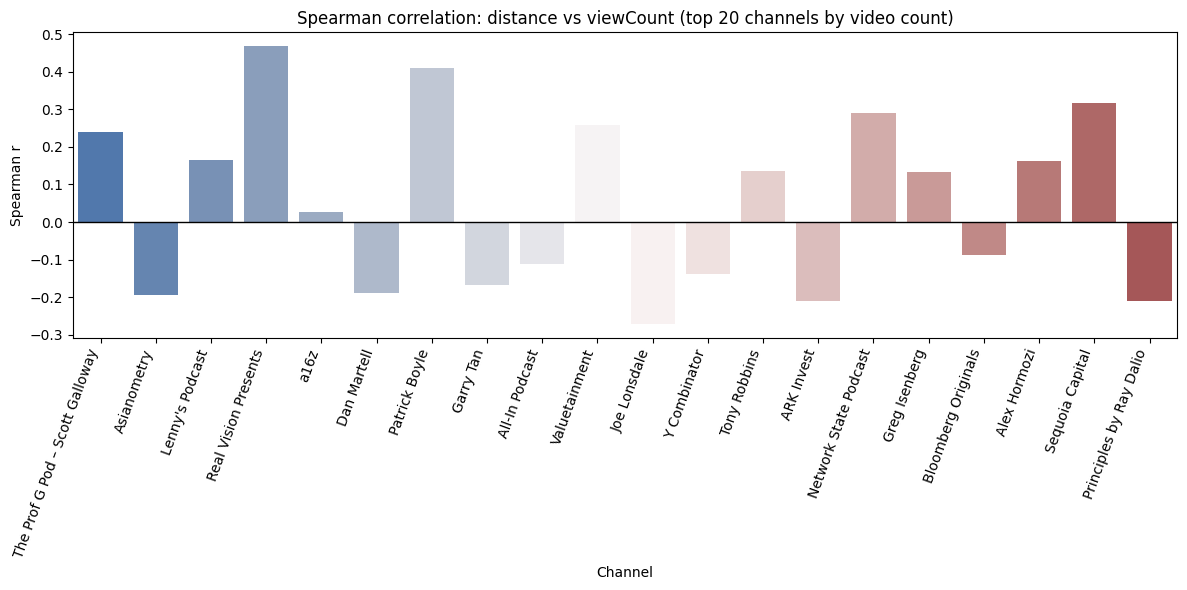

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: distribution of mean distances per channel
plt.figure(figsize=(10, 5))
sns.histplot(channel_corr_df['mean_distance'].dropna(), bins=20, kde=True)
plt.title('Distribution of channel mean cosine distance\n(video title -> channel description)')
plt.xlabel('Mean cosine distance')
plt.ylabel('Channel count')
plt.show()

# Chart 2: per-channel Spearman correlation (top channels by n_videos)
plot_df = channel_corr_df.dropna(subset=['spearman_distance_vs_views']).copy()
plot_df = plot_df.sort_values('n_videos', ascending=False).head(20)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='channelTitle', y='spearman_distance_vs_views', palette='vlag')
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=70, ha='right')
plt.title('Spearman correlation: distance vs viewCount (top 20 channels by video count)')
plt.xlabel('Channel')
plt.ylabel('Spearman r')
plt.tight_layout()
plt.show()


In [21]:
from google.colab import drive
from pathlib import Path
import json

drive.mount('/content/drive')

artifact_root = Path('/content/drive/MyDrive/Graphiko/analysis/video_title_to_channel_description_distance/latest')
artifact_root.mkdir(parents=True, exist_ok=True)

distance_csv_path = artifact_root / 'video_distances.csv'
channel_corr_csv_path = artifact_root / 'channel_correlations.csv'
summary_json_path = artifact_root / 'summary.json'

distance_df.to_csv(distance_csv_path, index=False)
channel_corr_df.to_csv(channel_corr_csv_path, index=False)

summary = {
    'artifact_root': str(artifact_root),
    'distance_csv': str(distance_csv_path),
    'channel_correlation_csv': str(channel_corr_csv_path),
    'n_channels_with_descriptions': int(len(channel_desc_text)),
    'n_video_titles': int(len(video_title_text)),
    'n_distance_rows': int(len(distance_df)),
    'n_channels_scored': int(len(channel_corr_df)),
    'corr_columns': ['pearson_distance_vs_views', 'spearman_distance_vs_views'],
}
summary_json_path.write_text(json.dumps(summary, indent=2))

print('Saved artifacts:')
print(' -', distance_csv_path)
print(' -', channel_corr_csv_path)
print(' -', summary_json_path)
summary


Mounted at /content/drive
Saved artifacts:
 - /content/drive/MyDrive/Graphiko/analysis/video_title_to_channel_description_distance/latest/video_distances.csv
 - /content/drive/MyDrive/Graphiko/analysis/video_title_to_channel_description_distance/latest/channel_correlations.csv
 - /content/drive/MyDrive/Graphiko/analysis/video_title_to_channel_description_distance/latest/summary.json


{'artifact_root': '/content/drive/MyDrive/Graphiko/analysis/video_title_to_channel_description_distance/latest',
 'distance_csv': '/content/drive/MyDrive/Graphiko/analysis/video_title_to_channel_description_distance/latest/video_distances.csv',
 'channel_correlation_csv': '/content/drive/MyDrive/Graphiko/analysis/video_title_to_channel_description_distance/latest/channel_correlations.csv',
 'n_channels_with_descriptions': 27,
 'n_video_titles': 1344,
 'n_distance_rows': 1344,
 'n_channels_scored': 27,
 'corr_columns': ['pearson_distance_vs_views', 'spearman_distance_vs_views']}

## How to read the results
- **Lower distance** means a video title is semantically closer to the channel description.
- **Negative correlation** (`distance vs viewCount`) suggests that more on-topic titles tend to attract more views for that channel.
- **Positive correlation** suggests off-topic or exploratory titles tend to receive more views.
- Correlations close to zero suggest title/description alignment is not a strong view predictor for that channel.

Use `channel_correlations.csv` as the per-channel leaderboard and inspect outlier channels with strong positive/negative correlations.
